Veri Toplama

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Veri Seti Yükleme

In [15]:
df = pd.read_csv('vgsales.csv')

Keşifsel Veri Analizi (EDA)

In [16]:
print("Veri Setinin Boyutu :", df.shape)
print("\nVeri Tipleri:\n", df.dtypes)
print("\nİlk 5 Satır:\n", df.head())
print("\nSon 5 Satır:\n", df.tail())
print("\nTemel İstatistikler:\n", df.describe())
print("\nEksik Değerlerin Sayısı:\n", df.isnull().sum())
print("\nBenzersiz Değer Sayısı:\n", df.nunique())
korelasyon = df.select_dtypes(include=[np.number]).corr()
print("\nKorelasyon Matrisi:\n", korelasyon)

Veri Setinin Boyutu : (16598, 11)

Veri Tipleri:
 Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

İlk 5 Satır:
    Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2    

Aykırı Değer Analizi ve Temizleme

In [17]:
aykiri_oncesi_satir = len(df)

Q1 = df['Global_Sales'].quantile(0.25)
Q3 = df['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

df = df[(df['Global_Sales'] >= alt_sinir) & (df['Global_Sales'] <= ust_sinir)]

print("Aykırı değer öncesi satır sayısı:", aykiri_oncesi_satir)
print("Aykırı değer sonrası satır sayısı:", len(df))
print("Silinen aykırı oyun sayısı:", aykiri_oncesi_satir - len(df))

Aykırı değer öncesi satır sayısı: 16598
Aykırı değer sonrası satır sayısı: 14705
Silinen aykırı oyun sayısı: 1893


Eksik Değer Analizi ve Temizleme

In [18]:
#Eksik değer öncesi satır ve sütun sayıları
eski_satir = len(df)
eski_sutun = len(df.columns)
print("Temizlik Öncesi Satır Sayısı: ", eski_satir)
print("Temizlik Öncesi Sütun Sayısı: ", eski_sutun)

# Yılların ortalaması alınamayacağı için Mod ile dolduruyorum.
df['Year'] = df['Year'].fillna(df['Year'].mode()[0])

# Yayıncı ismi eksik olan satırları siliyorum
df.dropna(subset=['Publisher'], inplace=True)

#Eksik değer sonrası satır ve sütun sayıları
yeni_satir = len(df)
yeni_sutun = len(df.columns)
print("\nYeni Satır Sayısı: ", yeni_satir)
print("Yeni Sütun Sayısı: ", yeni_sutun)

print("\nKalan boşluk sayısı: ", df.isnull().sum().sum())

Temizlik Öncesi Satır Sayısı:  14705
Temizlik Öncesi Sütun Sayısı:  11

Yeni Satır Sayısı:  14650
Yeni Sütun Sayısı:  11

Kalan boşluk sayısı:  0


Seaborn ile Görselleştirme

Bu grafik oyunların global satış dağılımını göstermektedir. Çoğu oyunun düşük satış yaptığı, az sayıda oyunun ise çok yüksek satış yaptığı görülmektedir.

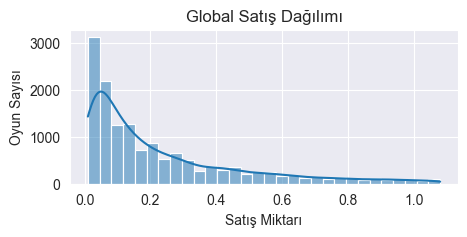

In [31]:
plt.figure(figsize=(5, 2))
sns.histplot(data=df, x='Global_Sales', kde=True, bins=30)
plt.title('Global Satış Dağılımı')
plt.xlabel('Satış Miktarı')
plt.ylabel('Oyun Sayısı')
plt.show()

Bu grafik oyun türlerinin global satış dağılımlarını göstermektedir. Bazı türlerde yüksek satış yapan aykırı değerler bulunmaktadır.

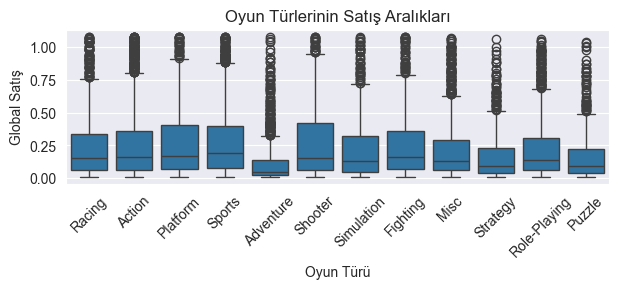

In [32]:
plt.figure(figsize=(7, 2))
sns.boxplot(data=df, x='Genre', y='Global_Sales')
plt.xticks(rotation=45)
plt.title('Oyun Türlerinin Satış Aralıkları')
plt.xlabel('Oyun Türü')
plt.ylabel('Global Satış')
plt.show()

Bu grafik oyunların yıllara göre dağılımını göstermektedir. Bazı yıllarda oyun üretiminin arttığı görülmektedir.

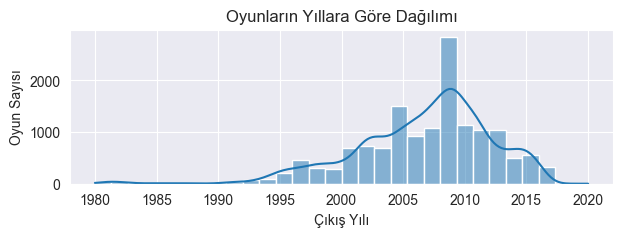

In [35]:
plt.figure(figsize=(7, 2))
sns.histplot(data=df, x='Year', kde=True, bins=30)
plt.title('Oyunların Yıllara Göre Dağılımı')
plt.xlabel('Çıkış Yılı')
plt.ylabel('Oyun Sayısı')
plt.show()

Bu grafik,satış bölgeleri arasındaki ilişkiyi sayısal olarak özetler.

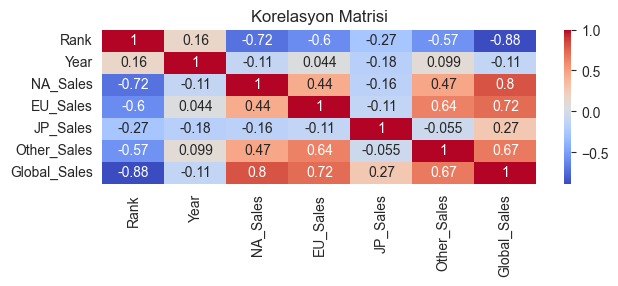

In [36]:
plt.figure(figsize=(7,2))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Korelasyon Matrisi')
plt.show()

Bu grafik veri setindeki oyun türlerinin dağılımını göstermektedir. En fazla üretilen oyun türleri gözlemlenmiştir.

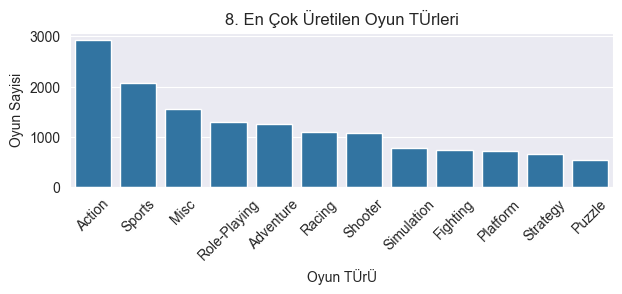

In [37]:
plt.figure(figsize=(7,2))
sns.countplot(data=df, x='Genre', order=df['Genre'].value_counts().index)
plt.xticks(rotation=45)
plt.title('8. En Çok Üretilen Oyun TÜrleri')
plt.xlabel('Oyun TÜrÜ')
plt.ylabel('Oyun Sayisi')
plt.show()

Bu grafik aksiyon ve spor oyunlarının çıkış yıllarının dağılımını göstermektedir.


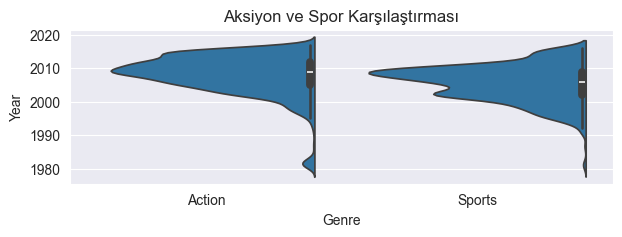

In [38]:
iki_tur = df[df['Genre'].isin(['Action', 'Sports'])]
plt.figure(figsize=(7,2))
sns.violinplot(data=iki_tur, x='Genre', y='Year', split=True)
plt.title('Aksiyon ve Spor Karşılaştırması')
plt.show()

Bu grafik, ilk 500 oyunun Kuzey Amerika (NA) ve Avrupa (EU) pazarlarındaki satış miktarları
arasındaki ilişkiyi göstermektedir.

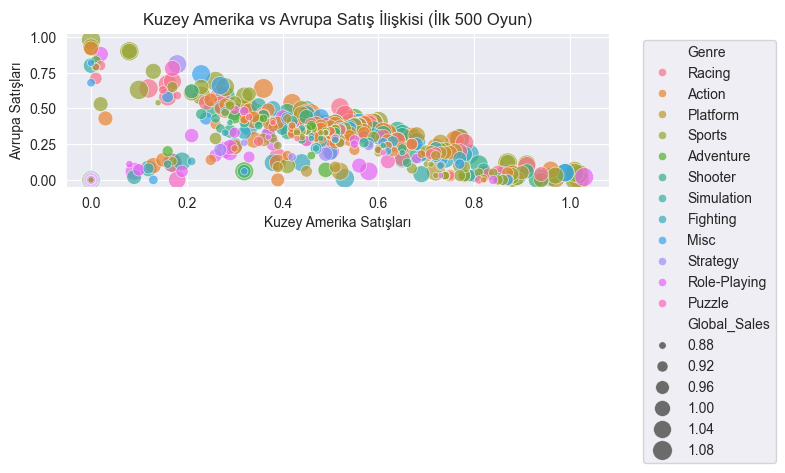

In [39]:
plt.figure(figsize=(7,2))
sns.scatterplot(data=df.head(500), x='NA_Sales', y='EU_Sales', hue='Genre', size='Global_Sales', sizes=(20, 200), alpha=0.7)
plt.title('Kuzey Amerika vs Avrupa Satış İlişkisi (İlk 500 Oyun)')
plt.xlabel('Kuzey Amerika Satışları')
plt.ylabel('Avrupa Satışları')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Veri setindeki en popüler 10 platformun oyun başına düşen ortalama global satış miktarını
karşılaştırmaktadır.

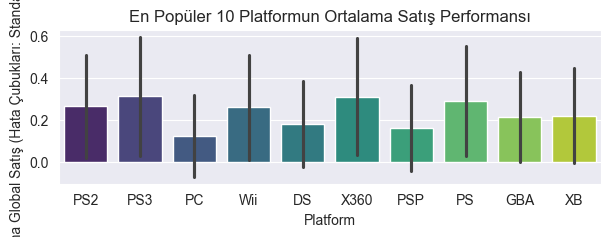

In [41]:
plt.figure(figsize=(7,2))
top_platforms = df['Platform'].value_counts().nlargest(10).index
subset_df = df[df['Platform'].isin(top_platforms)]

sns.barplot(data=subset_df, x='Platform', y='Global_Sales', errorbar='sd', hue='Platform', palette='viridis', legend=False)
plt.title('En Popüler 10 Platformun Ortalama Satış Performansı')
plt.xlabel('Platform')
plt.ylabel('Ortalama Global Satış (Hata Çubukları: Standart Sapma)')
plt.show()

Japonya ve Avrupadaki satışların yoğunluk dağılımını karşılaştıran grafik:

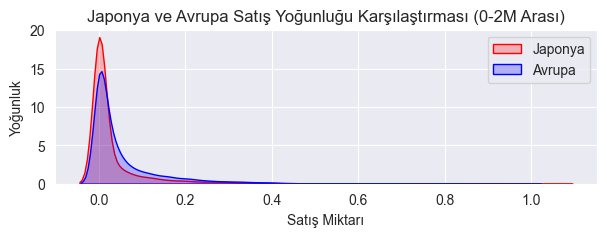

In [76]:
plt.figure(figsize=(7,2))
sns.kdeplot(data=df[df['Global_Sales'] < 2], x='JP_Sales', fill=True, label='Japonya', color='red')
sns.kdeplot(data=df[df['Global_Sales'] < 2], x='EU_Sales', fill=True, label='Avrupa', color='blue')
plt.title('Japonya ve Avrupa Satış Yoğunluğu Karşılaştırması (0-2M Arası)')
plt.xlabel('Satış Miktarı')
plt.ylabel('Yoğunluk')
plt.legend()
plt.show()

Bu grafik,Kuzey Amerika satışları ile toplam global satış arasındaki ilişkiyi göstermektedir.

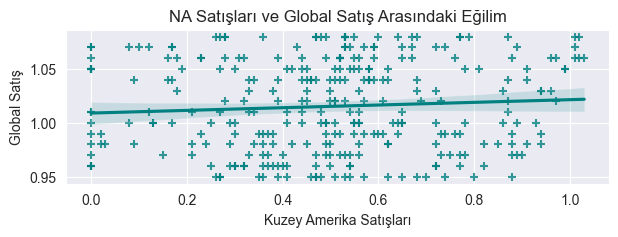

In [75]:
plt.figure(figsize=(7,2))
sns.regplot(data=df.head(300), x='NA_Sales', y='Global_Sales', color='teal', marker='+')

plt.title('NA Satışları ve Global Satış Arasındaki Eğilim')
plt.xlabel('Kuzey Amerika Satışları')
plt.ylabel('Global Satış')

plt.show()

GroupBy ve Koşullu Sorgular

Her oyun türünün Japonya pazarındaki ortalama satış başarısı hesaplanmıştır.

In [55]:
df.groupby('Genre')['JP_Sales'].mean().sort_values(ascending=False)

Genre
Role-Playing    0.103326
Fighting        0.070446
Strategy        0.062284
Puzzle          0.040416
Simulation      0.039641
Misc            0.037124
Sports          0.035265
Adventure       0.034140
Platform        0.028952
Action          0.028827
Shooter         0.015717
Racing          0.012096
Name: JP_Sales, dtype: float64

her yayıncının veri setinde toplam kaç adet oyunla yer aldığı belirlenmiştir.

In [57]:
df.groupby('Publisher')['Name'].count().sort_values(ascending=False).head(10)

Publisher
Electronic Arts                 1040
Namco Bandai Games               888
Activision                       825
Ubisoft                          821
Konami Digital Entertainment     774
THQ                              638
Sega                             575
Sony Computer Entertainment      546
Nintendo                         376
Tecmo Koei                       336
Name: Name, dtype: int64

yıllara göre global satışların aynı anda minimum, maksimum ve ortalama değerleri hesaplanmıştır.

In [58]:
# groupby + agg()
df.groupby('Year')['Global_Sales'].agg(['min', 'max', 'mean'])

,min,max,mean
Year,,,
1980.0,0.24,1.05,0.526667
1981.0,0.13,1.05,0.459167
1982.0,0.14,1.08,0.480667
1983.0,0.17,0.78,0.452000
1984.0,0.27,0.82,0.593333
1985.0,0.02,1.05,0.602222
1986.0,0.29,1.05,0.648000
1987.0,0.07,0.93,0.506667
1988.0,0.03,0.76,0.385000


Her oyun platformunun Avrupa genelinde ulaştığı toplam satış miktarları hesaplanmıştır.

In [60]:
# groupby + sum()
df.groupby('Platform')['EU_Sales'].sum().sort_values(ascending=False)

Platform
PS2     126.29
PS3     108.40
X360     91.78
PS       81.14
PC       69.97
Wii      66.10
DS       52.90
XB       39.45
GBA      35.89
PSP      34.72
PS4      25.44
GC       20.55
3DS      18.16
XOne     14.12
N64      13.83
PSV      12.14
WiiU     11.25
2600      2.70
NES       1.20
GB        0.56
SNES      0.35
SAT       0.12
DC        0.00
PCFX      0.00
NG        0.00
GEN       0.00
GG        0.00
3DO       0.00
SCD       0.00
WS        0.00
TG16      0.00
Name: EU_Sales, dtype: float64

Oyun türlerinin satış rakamlarındaki grup bazlı standart sapma değerleri incelenmiştir.

In [61]:
df.groupby('Genre')['Global_Sales'].std().sort_values(ascending=False)

Genre
Shooter         0.265851
Platform        0.263858
Fighting        0.257741
Racing          0.255125
Sports          0.255088
Action          0.245592
Simulation      0.238002
Role-Playing    0.237054
Misc            0.225184
Puzzle          0.206208
Strategy        0.197158
Adventure       0.168466
Name: Global_Sales, dtype: float64

Hem Aksiyon türünde olan hem de Kuzey Amerika'da belirli bir eşik değerin (1 milyon) üzerinde satış yapan oyunlar filtrelenmiştir.

In [62]:
df.loc[(df['Genre'] == 'Action') & (df['NA_Sales'] > 1)]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
1901,1903,NCAA Football 13,X360,2012.0,Action,Electronic Arts,1.02,0.0,0.0,0.06,1.08


2000-2010 yılları arasında çıkan ve global satışı 5 milyonun üzerinde olan oyunlar filtrelenmiştir.

In [67]:
df.query("Year >= 2000 and Year <= 2010 and Global_Sales >0.5")

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Genre_Avg
1893,1895,NASCAR Thunder 2004,PS2,2003.0,Racing,Electronic Arts,0.53,0.41,0.00,0.14,1.08,0.246700
1894,1896,Prince of Persia,PS3,2008.0,Action,Ubisoft,0.47,0.41,0.03,0.18,1.08,0.247118
1895,1897,SpongeBob SquarePants: Revenge of the Flying D...,PS2,2002.0,Platform,THQ,0.53,0.41,0.00,0.14,1.08,0.273244
1897,1899,The Biggest Loser,Wii,2009.0,Sports,THQ,0.87,0.12,0.00,0.09,1.08,0.275767
1898,1900,Fisherman's Bass Club,PS2,2002.0,Sports,Agetec,0.53,0.41,0.00,0.14,1.08,0.275767
...,...,...,...,...,...,...,...,...,...,...,...,...
3938,3940,NBA Ballers,XB,2004.0,Sports,Midway Games,0.37,0.11,0.00,0.02,0.51,0.275767
3939,3941,Silent Hill 4: The Room,PS2,2004.0,Action,Konami Digital Entertainment,0.25,0.19,0.00,0.06,0.51,0.247118
3941,3943,Capcom Classics Collection,PS2,2005.0,Misc,Capcom,0.22,0.17,0.05,0.06,0.51,0.217413
3944,3946,Monopoly Party,PS2,2002.0,Misc,Infogrames,0.25,0.19,0.00,0.06,0.51,0.217413


Global satış ortalaması belirli bir sınırın (örneğin 0.5) altında kalan türlerin tüm satırları veri setinden elenmiştir.


In [68]:
df.groupby('Genre').filter(lambda x: x['Global_Sales'].mean() > 0.1)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Genre_Avg
1893,1895,NASCAR Thunder 2004,PS2,2003.0,Racing,Electronic Arts,0.53,0.41,0.00,0.14,1.08,0.246700
1894,1896,Prince of Persia,PS3,2008.0,Action,Ubisoft,0.47,0.41,0.03,0.18,1.08,0.247118
1895,1897,SpongeBob SquarePants: Revenge of the Flying D...,PS2,2002.0,Platform,THQ,0.53,0.41,0.00,0.14,1.08,0.273244
1896,1898,Grand Theft Auto V,PC,2015.0,Action,Take-Two Interactive,0.36,0.64,0.00,0.08,1.08,0.247118
1897,1899,The Biggest Loser,Wii,2009.0,Sports,THQ,0.87,0.12,0.00,0.09,1.08,0.275767
...,...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01,0.273244
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01,0.265158
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01,0.246700
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01,0.171739


Her oyunun kendi türüne ait global satış ortalaması hesaplanmış ve bu istatistik tüm satırlara yayılmıştır.

In [65]:
df['Genre_Avg'] = df.groupby('Genre')['Global_Sales'].transform('mean')
df[['Name', 'Genre', 'Global_Sales', 'Genre_Avg']].head()

,Name,Genre,Global_Sales,Genre_Avg
1893,NASCAR Thunder 2004,Racing,1.08,0.246700
1894,Prince of Persia,Action,1.08,0.247118
1895,SpongeBob SquarePants: Revenge of the Flying D...,Platform,1.08,0.273244
1896,Grand Theft Auto V,Action,1.08,0.247118
1897,The Biggest Loser,Sports,1.08,0.275767


Globalde en çok satan ilk 10 oyun

In [66]:
df.sort_values(by='Global_Sales', ascending=False).head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Genre_Avg
1893,1895,NASCAR Thunder 2004,PS2,2003.0,Racing,Electronic Arts,0.53,0.41,0.00,0.14,1.08,0.246700
1894,1896,Prince of Persia,PS3,2008.0,Action,Ubisoft,0.47,0.41,0.03,0.18,1.08,0.247118
1895,1897,SpongeBob SquarePants: Revenge of the Flying D...,PS2,2002.0,Platform,THQ,0.53,0.41,0.00,0.14,1.08,0.273244
1896,1898,Grand Theft Auto V,PC,2015.0,Action,Take-Two Interactive,0.36,0.64,0.00,0.08,1.08,0.247118
1897,1899,The Biggest Loser,Wii,2009.0,Sports,THQ,0.87,0.12,0.00,0.09,1.08,0.275767
1898,1900,Fisherman's Bass Club,PS2,2002.0,Sports,Agetec,0.53,0.41,0.00,0.14,1.08,0.275767
1899,1901,MySims Agents,DS,2009.0,Adventure,Electronic Arts,0.55,0.43,0.00,0.11,1.08,0.120595
1900,1902,Resident Evil: The Darkside Chronicles,Wii,2009.0,Action,Capcom,0.48,0.32,0.20,0.09,1.08,0.247118
1901,1903,NCAA Football 13,X360,2012.0,Action,Electronic Arts,1.02,0.00,0.00,0.06,1.08,0.247118
1902,1904,Grand Theft Auto: Chinatown Wars,PSP,2009.0,Action,Take-Two Interactive,0.28,0.50,0.03,0.28,1.08,0.247118


Makine Öğrenmesi Modeli: Satış Tahmini

Bu bölümde oyunların türü, platformu ve yayıncısı gibi özellikler kullanılarak dünya genelindeki toplam satış miktarları (Global_Sales) tahmin edilmektedir. Performans ölçümü için Linear Regression ve Random Forest Regressor modelleri karşılaştırılmıştır.

In [74]:
features = ['Platform', 'Genre', 'Publisher']
X = df[features].copy()
y = df['Global_Sales']

le = LabelEncoder()
for col in features:
    X[col] = le.fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"--- {name} Sonuçları ---")
    print(f"MAE: {mean_absolute_error(y_test, preds):.4f}")
    print(f"R² Skoru: {r2_score(y_test, preds):.4f}\n")

--- Linear Regression Sonuçları ---
MAE: 0.1896
R² Skoru: 0.0068

--- Random Forest Regressor Sonuçları ---
MAE: 0.1596
R² Skoru: 0.1878



Model Değerlendirme ve Yorum

MAE (Ortalama Mutlak Hata):
Modelimiz satış tahminlerinde ortalama 0.1596 yanılma payına sahiptir. Bu hata oranı, modelin
genel satış eğilimini makul bir şekilde yakaladığını göstermektedir.

RMSE (Kök Ortalama Kare Hata):
RMSE değerinin MAE'den yüksek çıkması, bazı yüksek satışlı oyunları tahmin etmenin daha zor olduğunu
kanıtlamaktadır. Yine de yapılan aykırı değer temizliği sayesinde genel tahmin tutarlılığı artmıştır.

R² Skoru:
Elde edilen %18.78'lik skor, sadece tür ve platform gibi kısıtlı bilgilerle yapılan bir tahmin için
tutarlıdır. Özellikle Linear Regression'ın sıfıra yakın (0.0068) sonucuna kıyasla Random Forest
modelinin çok daha iyi çalıştığı görülmektedir.